In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
train_path = "../data/raw/train_FD001.txt"

train_df = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("Dataset shape:", train_df.shape)

train_df.head()

Dataset shape: (20631, 26)


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
print("Dataset shape:", train_df.shape)
train_df.head()

Dataset shape: (20631, 26)


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
column_names = (
    ["unit_id", "cycle"]
    + ["setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train_df.columns = column_names

print("Column names assigned successfully!")

train_df.head()

Column names assigned successfully!


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [8]:
print("Total columns:", len(train_df.columns))

for column in train_df.columns:
    print(column)

Total columns: 26
unit_id
cycle
setting_1
setting_2
setting_3
sensor_1
sensor_2
sensor_3
sensor_4
sensor_5
sensor_6
sensor_7
sensor_8
sensor_9
sensor_10
sensor_11
sensor_12
sensor_13
sensor_14
sensor_15
sensor_16
sensor_17
sensor_18
sensor_19
sensor_20
sensor_21


In [9]:
# Basic dataset validation

print("===== FD001 TRAINING DATA SUMMARY =====")

# 1. Dataset shape
print("\nDataset shape:")
print(train_df.shape)

# 2. Number of unique engines
print("\nNumber of unique engines:")
print(train_df["unit_id"].nunique())

# 3. Missing values
print("\nTotal missing values:")
print(train_df.isnull().sum().sum())

# 4. Duplicate rows
print("\nNumber of duplicate rows:")
print(train_df.duplicated().sum())

# 5. Cycle range
print("\nMinimum cycle:")
print(train_df["cycle"].min())

print("\nMaximum cycle:")
print(train_df["cycle"].max())

===== FD001 TRAINING DATA SUMMARY =====

Dataset shape:
(20631, 26)

Number of unique engines:
100

Total missing values:
0

Number of duplicate rows:
0

Minimum cycle:
1

Maximum cycle:
362


In [10]:
# Find the maximum cycle reached by each engine
engine_lifetime = train_df.groupby("unit_id")["cycle"].max()

print("Engine lifetime summary:")
print(engine_lifetime.head(10))

Engine lifetime summary:
unit_id
1     192
2     287
3     179
4     189
5     269
6     188
7     259
8     150
9     201
10    222
Name: cycle, dtype: int64


In [11]:
# Statistical summary of engine lifetimes
print("Engine lifetime statistics:")
print(engine_lifetime.describe())

Engine lifetime statistics:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


In [12]:
# Create maximum cycle column for each engine
train_df["max_cycle"] = train_df.groupby("unit_id")["cycle"].transform("max")

# Calculate Remaining Useful Life (RUL)
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]

print("RUL column created successfully!")

# Display important columns
train_df[["unit_id", "cycle", "max_cycle", "RUL"]].head(10)

RUL column created successfully!


,unit_id,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


In [13]:
# Verify the last 5 cycles of Engine 1
train_df[
    train_df["unit_id"] == 1
][["unit_id", "cycle", "max_cycle", "RUL"]].tail()

,unit_id,cycle,max_cycle,RUL
187,1,188,192,4
188,1,189,192,3
189,1,190,192,2
190,1,191,192,1
191,1,192,192,0


In [14]:
# Validate RUL calculation for all engines

final_rul_per_engine = train_df.groupby("unit_id")["RUL"].min()

print("Number of engines:", len(final_rul_per_engine))
print("Minimum final RUL:", final_rul_per_engine.min())
print("Maximum final RUL:", final_rul_per_engine.max())

# Check whether every engine ends with RUL = 0
all_engines_end_at_zero = (final_rul_per_engine == 0).all()

print("Do all engines end with RUL = 0?")
print(all_engines_end_at_zero)

Number of engines: 100
Minimum final RUL: 0
Maximum final RUL: 0
Do all engines end with RUL = 0?
True


In [15]:
# Remove helper column before saving
processed_train_df = train_df.drop(columns=["max_cycle"])

# Save processed FD001 training dataset
output_path = "../data/processed/train_FD001_processed.csv"

processed_train_df.to_csv(output_path, index=False)

print("Processed dataset saved successfully!")
print("Saved at:", output_path)
print("Final shape:", processed_train_df.shape)

Processed dataset saved successfully!
Saved at: ../data/processed/train_FD001_processed.csv
Final shape: (20631, 27)


## Exploratory Data Analysis (EDA)

In this section, we analyze engine lifetimes and sensor behavior to understand degradation patterns before building the machine learning model.

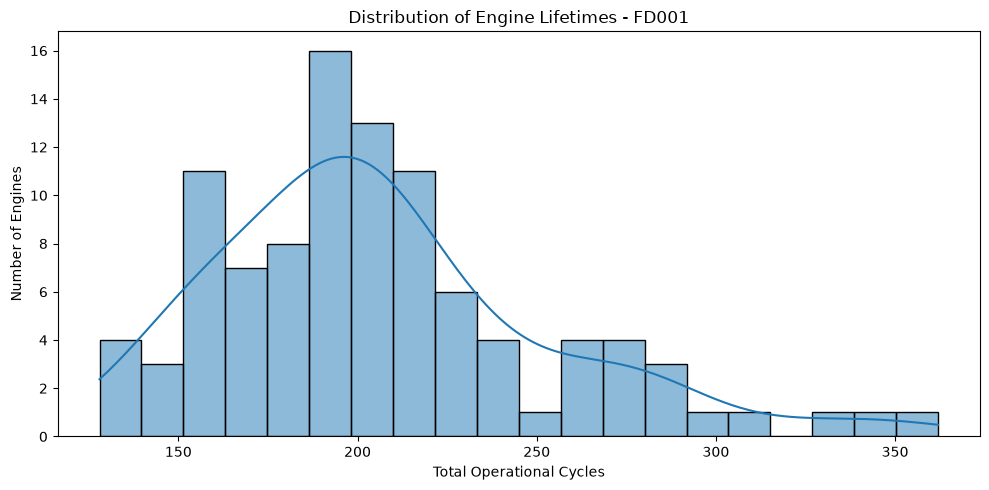

In [16]:
# Plot distribution of engine lifetimes

plt.figure(figsize=(10, 5))

sns.histplot(
    engine_lifetime,
    bins=20,
    kde=True
)

plt.title("Distribution of Engine Lifetimes - FD001")
plt.xlabel("Total Operational Cycles")
plt.ylabel("Number of Engines")

plt.tight_layout()
plt.show()

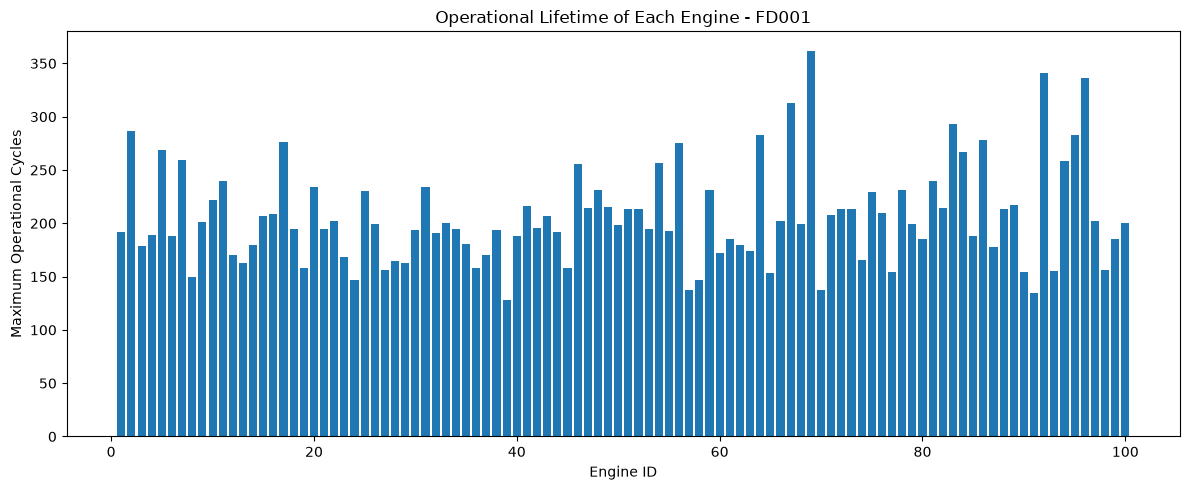

In [17]:
# Plot lifetimes of all 100 engines

plt.figure(figsize=(12, 5))

plt.bar(
    engine_lifetime.index,
    engine_lifetime.values
)

plt.title("Operational Lifetime of Each Engine - FD001")
plt.xlabel("Engine ID")
plt.ylabel("Maximum Operational Cycles")

plt.tight_layout()
plt.show()

### Sensor Trend Analysis

We analyze sensor measurements across operational cycles to identify degradation patterns as an engine approaches failure.

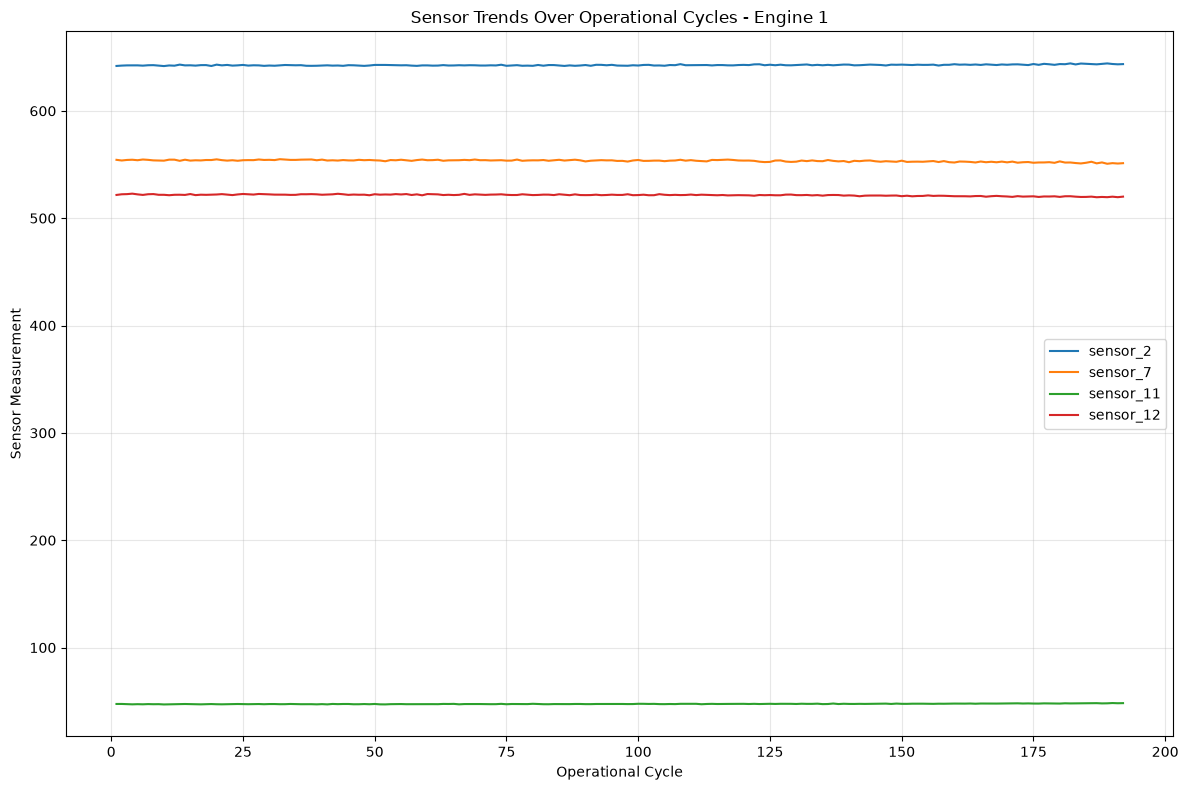

In [18]:
# Select Engine 1 data
engine_1 = train_df[train_df["unit_id"] == 1]

# Sensors to analyze
selected_sensors = ["sensor_2", "sensor_7", "sensor_11", "sensor_12"]

plt.figure(figsize=(12, 8))

for sensor in selected_sensors:
    plt.plot(
        engine_1["cycle"],
        engine_1[sensor],
        label=sensor
    )

plt.title("Sensor Trends Over Operational Cycles - Engine 1")
plt.xlabel("Operational Cycle")
plt.ylabel("Sensor Measurement")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

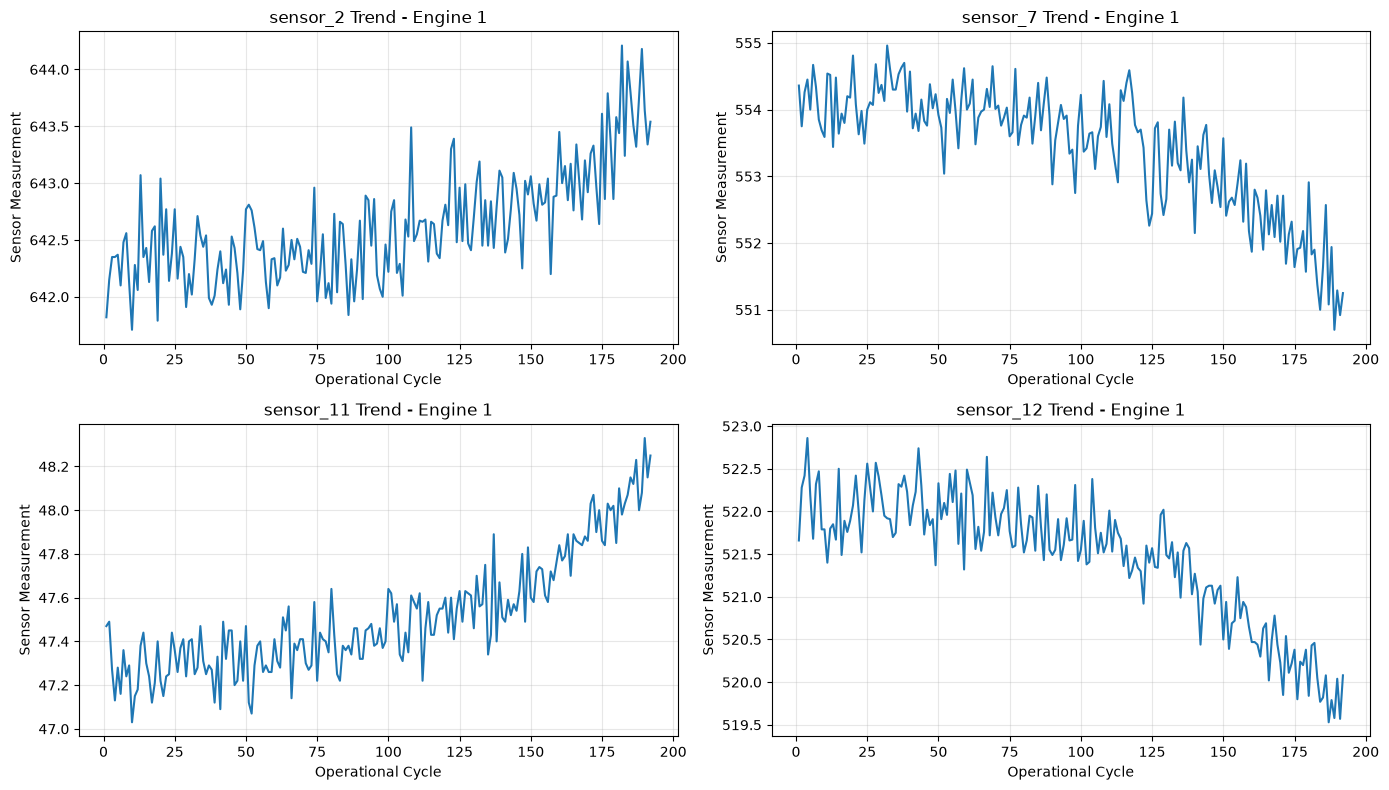

In [19]:
# Plot selected sensors separately

selected_sensors = ["sensor_2", "sensor_7", "sensor_11", "sensor_12"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes = axes.flatten()

for i, sensor in enumerate(selected_sensors):
    axes[i].plot(
        engine_1["cycle"],
        engine_1[sensor]
    )

    axes[i].set_title(f"{sensor} Trend - Engine 1")
    axes[i].set_xlabel("Operational Cycle")
    axes[i].set_ylabel("Sensor Measurement")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Sensor Variability Analysis

We analyze sensor variability across the complete FD001 training dataset. Sensors with constant or near-constant values may provide little useful information for predicting Remaining Useful Life.

In [20]:
# Get all sensor column names
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

# Calculate number of unique values and standard deviation
sensor_analysis = pd.DataFrame({
    "unique_values": train_df[sensor_columns].nunique(),
    "standard_deviation": train_df[sensor_columns].std()
})

sensor_analysis

,unique_values,standard_deviation
sensor_1,1,0.000000e+00
sensor_2,310,5.000533e-01
sensor_3,3012,6.131150e+00
sensor_4,4051,9.000605e+00
sensor_5,1,5.329200e-15
sensor_6,2,1.388985e-03
sensor_7,513,8.850923e-01
sensor_8,53,7.098548e-02
sensor_9,6403,2.208288e+01
sensor_10,1,0.000000e+00


In [21]:
# Identify constant sensors
constant_sensors = sensor_analysis[
    sensor_analysis["unique_values"] == 1
]

print("Constant sensors:")
print(constant_sensors)

Constant sensors:
           unique_values  standard_deviation
sensor_1               1        0.000000e+00
sensor_5               1        5.329200e-15
sensor_10              1        0.000000e+00
sensor_16              1        3.469531e-18
sensor_18              1        0.000000e+00
sensor_19              1        0.000000e+00


In [22]:
# Sort sensors by standard deviation
sensor_analysis.sort_values(
    by="standard_deviation"
)

,unique_values,standard_deviation
sensor_1,1,0.000000e+00
sensor_10,1,0.000000e+00
sensor_19,1,0.000000e+00
sensor_18,1,0.000000e+00
sensor_16,1,3.469531e-18
sensor_5,1,5.329200e-15
sensor_6,2,1.388985e-03
sensor_15,1918,3.750504e-02
sensor_8,53,7.098548e-02
sensor_13,56,7.191892e-02


### Feature Selection

Constant sensors are removed because they do not vary across the FD001 training dataset and therefore provide no useful information for Remaining Useful Life prediction.

In [23]:
# List of constant sensors identified from the dataset
constant_sensor_names = constant_sensors.index.tolist()

print("Sensors to remove:")
print(constant_sensor_names)

# Keep all non-constant sensors
selected_sensor_columns = [
    sensor for sensor in sensor_columns
    if sensor not in constant_sensor_names
]

print("\nNumber of selected sensors:", len(selected_sensor_columns))
print("\nSelected sensors:")
print(selected_sensor_columns)

Sensors to remove:
['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Number of selected sensors: 15

Selected sensors:
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [24]:
# Create the initial model feature list

feature_columns = (
    ["setting_1", "setting_2", "setting_3"]
    + selected_sensor_columns
)

print("Total model features:", len(feature_columns))
print("\nFeature columns:")
print(feature_columns)

Total model features: 18

Feature columns:
['setting_1', 'setting_2', 'setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [25]:
# Create final processed dataset for model building
final_processed_df = train_df[
    ["unit_id", "cycle"]
    + feature_columns
    + ["RUL"]
].copy()

# Save final processed dataset
final_output_path = "../data/processed/train_FD001_processed.csv"

final_processed_df.to_csv(
    final_output_path,
    index=False
)

print("Final processed dataset saved successfully!")
print("Saved at:", final_output_path)
print("Final shape:", final_processed_df.shape)

Final processed dataset saved successfully!
Saved at: ../data/processed/train_FD001_processed.csv
Final shape: (20631, 21)


In [26]:
# Verify the saved processed dataset
check_df = pd.read_csv(
    "../data/processed/train_FD001_processed.csv"
)

print("Saved dataset shape:", check_df.shape)
print("\nColumns:")
print(check_df.columns.tolist())

check_df.head()

Saved dataset shape: (20631, 21)

Columns:
['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL']


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,21.61,554.36,...,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,21.61,553.75,...,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,21.61,554.26,...,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,21.61,554.45,...,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,21.61,554.00,...,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [27]:
# Check minimum and maximum values of all selected sensors

sensor_ranges = train_df[sensor_columns].agg(["min", "max"]).T

sensor_ranges

,min,max
sensor_1,518.6700,518.6700
sensor_2,641.2100,644.5300
sensor_3,1571.0400,1616.9100
sensor_4,1382.2500,1441.4900
sensor_5,14.6200,14.6200
sensor_6,21.6000,21.6100
sensor_7,549.8500,556.0600
sensor_8,2387.9000,2388.5600
sensor_9,9021.7300,9244.5900
sensor_10,1.3000,1.3000


In [28]:
# Check ranges of important sensors

important_sensors = [
    "sensor_11",
    "sensor_9",
    "sensor_4",
    "sensor_12",
    "sensor_14"
]

train_df[important_sensors].agg(["min", "max"]).T

,min,max
sensor_11,46.85,48.53
sensor_9,9021.73,9244.59
sensor_4,1382.25,1441.49
sensor_12,518.69,523.38
sensor_14,8099.94,8293.72
